# Track 3: Risk & Financial Analysis — Solution Notebook

**Bank Loan & Credit Risk Stress Test**  
**Questions covered:** 1, 2, 3, 4, 5, 7, 8, 12

This notebook accompanies the Word deliverable. It loads the loan dataset, then walks through each analytical question with executable code, real numerical results, and explanatory commentary.

**Dataset used**

- `loan_data.csv` — 45,000 loan records, 14 columns (borrower demographics, loan attributes, credit history, default status)

---
## 0. Setup — Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import sqlite3
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
np.random.seed(42)

df = pd.read_csv('loan_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Dataset shape: (45000, 14)
Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']


In [2]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
# Quick health check -- nulls and dtypes
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isna().sum(),
    'unique': df.nunique()
})
summary

,dtype,nulls,unique
person_age,float64,0,60
person_gender,str,0,2
person_education,str,0,5
person_income,float64,0,33989
person_emp_exp,int64,0,63
person_home_ownership,str,0,4
loan_amnt,float64,0,4483
loan_intent,str,0,6
loan_int_rate,float64,0,1302
loan_percent_income,float64,0,64


---
## Question 1 — Apply 2NF and 3NF to Separate Borrower from Loan Data

**Problem**: the raw flat file mixes three concerns in every row — borrower demographics, credit history, and loan transaction details. If a single borrower takes 3 loans, their age, gender, education, and income are repeated 3 times. This causes update anomalies, wasted storage, and risks data integrity.

**Plan**: split into 3 normalized tables.

| Table | Grain | Columns |
|---|---|---|
| `borrowers` | one row per borrower | person_age, person_gender, person_education, person_income, person_emp_exp, person_home_ownership |
| `credit_history` | one row per borrower (1:1) | cb_person_cred_hist_length, credit_score, previous_loan_defaults_on_file |
| `loans` | one row per loan | loan_amnt, loan_intent, loan_int_rate, loan_percent_income, loan_status |

**Why split credit_history from borrowers?** It satisfies 3NF — credit attributes depend on the borrower (not on any loan), but they evolve independently of the borrower's static demographics, so a separate table is appropriate when credit data is updated on a different cadence than personal info.

In [4]:
# Demonstrate the normalization split in pandas
df_norm = df.copy()
df_norm['borrower_id'] = range(1, len(df_norm) + 1)
df_norm['loan_id'] = range(1, len(df_norm) + 1)

borrowers = df_norm[['borrower_id', 'person_age', 'person_gender',
                     'person_education', 'person_income', 'person_emp_exp',
                     'person_home_ownership']]

credit_history = df_norm[['borrower_id', 'cb_person_cred_hist_length',
                          'credit_score', 'previous_loan_defaults_on_file']]

loans = df_norm[['loan_id', 'borrower_id', 'loan_amnt', 'loan_intent',
                 'loan_int_rate', 'loan_percent_income', 'loan_status']]

print(f'borrowers:      {borrowers.shape}')
print(f'credit_history: {credit_history.shape}')
print(f'loans:          {loans.shape}')
print()
print('borrowers sample:')
print(borrowers.head(3).to_string(index=False))

borrowers:      (45000, 7)
credit_history: (45000, 4)
loans:          (45000, 7)

borrowers sample:
 borrower_id  person_age person_gender person_education  person_income  person_emp_exp person_home_ownership
           1        22.0        female           Master        71948.0               0                  RENT
           2        21.0        female      High School        12282.0               0                   OWN
           3        25.0        female      High School        12438.0               3              MORTGAGE


**Note on the demonstration**: In this dataset, each row has unique borrower attributes, so we generated a 1:1 borrower_id ↔ loan_id mapping. In a real production system, you would deduplicate by a true borrower identifier (SSN, national ID, or hashed equivalent) so that one borrower with multiple loans occupies one row in `borrowers` and N rows in `loans`.

---
## Question 2 — FULL OUTER JOIN: Reconcile Applications vs Funded Loans

**Business context**: the bank's Risk Committee needs to reconcile two operational systems — **applications** (every loan request) and **funded_loans** (every disbursement). A FULL OUTER JOIN surfaces both sides of the discrepancy.

**Setup**: derive two tables from the raw CSV with intentional overlap and gaps to simulate real-world reconciliation.

In [5]:
# Add a synthetic application_id (the join key)
df['application_id'] = ['APP-' + str(i).zfill(6) for i in range(len(df))]

# applications = 99% of records (simulating tiny intake gaps)
applications = df.sample(frac=0.99, random_state=1).copy()

# funded_loans = 90% of records (10% of applications never funded)
funded_loans = df.sample(frac=0.90, random_state=2).copy()

print(f'applications: {len(applications):,} rows')
print(f'funded_loans: {len(funded_loans):,} rows')

applications: 44,550 rows
funded_loans: 40,500 rows


In [6]:
# Run the FULL OUTER JOIN via SQL (SQLite >=3.39 supports FULL OUTER JOIN)
con = sqlite3.connect(':memory:')
applications[['application_id', 'loan_amnt']].to_sql(
    'applications', con, index=False, if_exists='replace')
funded_loans[['application_id', 'loan_amnt']].to_sql(
    'funded_loans', con, index=False, if_exists='replace')

summary_query = '''
SELECT
    CASE
        WHEN a.application_id IS NULL THEN 'FUNDED_NO_APPLICATION'
        WHEN f.application_id IS NULL THEN 'APPLIED_NOT_FUNDED'
        ELSE 'MATCHED'
    END AS reconciliation_status,
    COUNT(*) AS record_count
FROM applications a
FULL OUTER JOIN funded_loans f
    ON a.application_id = f.application_id
GROUP BY 1
ORDER BY record_count DESC;
'''
summary = pd.read_sql(summary_query, con)
summary

,reconciliation_status,record_count
0,MATCHED,40092
1,APPLIED_NOT_FUNDED,4458
2,FUNDED_NO_APPLICATION,408


In [7]:
# Show a sample of each discrepancy class
discrepancy_query = '''
SELECT
    COALESCE(a.application_id, f.application_id) AS application_id,
    a.loan_amnt AS requested_amount,
    f.loan_amnt AS funded_amount,
    CASE
        WHEN a.application_id IS NULL THEN 'FUNDED_NO_APPLICATION'
        WHEN f.application_id IS NULL THEN 'APPLIED_NOT_FUNDED'
    END AS reconciliation_status
FROM applications a
FULL OUTER JOIN funded_loans f
    ON a.application_id = f.application_id
WHERE a.application_id IS NULL OR f.application_id IS NULL
ORDER BY reconciliation_status, application_id
LIMIT 10;
'''
pd.read_sql(discrepancy_query, con)

,application_id,requested_amount,funded_amount,reconciliation_status
0,APP-000009,1600.0,None,APPLIED_NOT_FUNDED
1,APP-000012,35000.0,None,APPLIED_NOT_FUNDED
2,APP-000024,33950.0,None,APPLIED_NOT_FUNDED
3,APP-000036,30000.0,None,APPLIED_NOT_FUNDED
4,APP-000046,18000.0,None,APPLIED_NOT_FUNDED
5,APP-000047,30000.0,None,APPLIED_NOT_FUNDED
6,APP-000056,20000.0,None,APPLIED_NOT_FUNDED
7,APP-000065,1500.0,None,APPLIED_NOT_FUNDED
8,APP-000069,25000.0,None,APPLIED_NOT_FUNDED
9,APP-000074,28000.0,None,APPLIED_NOT_FUNDED


**Risk Committee findings**

- **40,092 matched** records — clean reconciliation
- **4,458 APPLIED_NOT_FUNDED** (~10% drop-off) — normal funnel leak; investigate whether borrowers walked away due to high rates, KYC failure, or competitor offers
- **408 FUNDED_NO_APPLICATION** — **control failure**. Loans were disbursed without a matching application record. Audit and compliance must investigate immediately.

---
## Question 3 — Variance in Interest Rates: Is Risk Pricing Standardized?

**Hypothesis to test**: a well-run lender prices risk consistently — meaning borrowers with similar credit profiles should receive similar rates. Excessive variance within a credit band suggests pricing is **not** standardized.

In [8]:
ir = df['loan_int_rate']
print(f'n:        {len(ir):,}')
print(f'mean:     {ir.mean():.4f}%')
print(f'std dev:  {ir.std():.4f}%')
print(f'variance: {ir.var():.4f}')
print(f'min:      {ir.min():.2f}%')
print(f'max:      {ir.max():.2f}%')
print(f'range:    {ir.max() - ir.min():.2f} percentage points')
print(f'CV:       {(ir.std() / ir.mean()) * 100:.2f}% (coefficient of variation)')

n:        45,000
mean:     11.0066%
std dev:  2.9788%
variance: 8.8733
min:      5.42%
max:      20.00%
range:    14.58 percentage points
CV:       27.06% (coefficient of variation)


In [9]:
# Variance broken down by credit score band -- the real test
df['credit_band'] = pd.cut(
    df['credit_score'],
    bins=[0, 580, 670, 740, 850],
    labels=['Poor (<580)', 'Fair (580-669)', 'Good (670-739)', 'Excellent (740+)']
)
by_band = df.groupby('credit_band', observed=True)['loan_int_rate'].agg(
    ['mean', 'std', 'var', 'count']
).round(4)
by_band

,mean,std,var,count
credit_band,,,,
Poor (<580),10.9271,2.9323,8.5985,7074
Fair (580-669),11.0136,2.9870,8.9220,26992
Good (670-739),11.0404,2.9872,8.9231,10846
Excellent (740+),11.0773,3.0858,9.5219,88


**Interpretation**

- Overall variance is **8.87** (std = 2.98%) on a mean of 11.01% — a coefficient of variation of **27%**, which is high for a regulated pricing variable.
- The far more telling result is the **breakdown by credit band**: every band (Poor, Fair, Good, Excellent) has nearly identical variance (8.6–9.5) and almost identical mean rates (10.93% to 11.08%).
- **In a properly risk-priced book**, Poor-credit borrowers should receive *higher* mean rates and the within-band variance should be *small*. Here we see neither.

> **Conclusion**: Yes, the high overall variance combined with flat mean rates across credit bands strongly suggests **risk pricing is not standardized**. Borrowers are receiving rates that are largely uncorrelated with their credit quality — pricing appears to be driven by other factors (loan officer discretion? campaign promotions? channel?). This is a material finding for the Risk Committee.

---
## Question 4 — T-Test: Income Difference Between Defaulted and Current Borrowers

**Null hypothesis (H₀)**: there is no difference in mean income between defaulted borrowers (loan_status=1) and current borrowers (loan_status=0).  
**Alternative (H₁)**: the means differ.  
**Significance level**: α = 0.05

We use **Welch's t-test** (unequal variances) because the two groups are likely to have different variances — and the data confirms this.

In [10]:
default = df[df['loan_status'] == 1]['person_income']
current = df[df['loan_status'] == 0]['person_income']

summary = pd.DataFrame({
    'group':   ['Defaulted', 'Current'],
    'n':       [len(default), len(current)],
    'mean':    [default.mean(), current.mean()],
    'std':     [default.std(), current.std()],
    'median':  [default.median(), current.median()]
}).round(2)
summary

,group,n,mean,std,median
0,Defaulted,10000,59886.10,45338.32,50629.0
1,Current,35000,86157.04,87035.24,72928.0


In [11]:
# Welch's t-test (does not assume equal variances)
t_stat, p_value = stats.ttest_ind(default, current, equal_var=False)

# 95% CI for the difference in means
diff = current.mean() - default.mean()
se_diff = np.sqrt(default.var() / len(default) + current.var() / len(current))
ci_low, ci_high = diff - 1.96 * se_diff, diff + 1.96 * se_diff

print(f'Difference in means (current - default): ${diff:,.2f}')
print(f't-statistic:                              {t_stat:.4f}')
print(f'p-value:                                  {p_value:.4e}')
print(f'95% CI for mean difference:               (${ci_low:,.0f}, ${ci_high:,.0f})')

Difference in means (current - default): $26,270.94
t-statistic:                              -40.4413
p-value:                                  0.0000e+00
95% CI for mean difference:               ($24,998, $27,544)


**Interpretation**

- The difference in mean income is **$26,271** — current borrowers earn substantially more on average than defaulted borrowers.
- The **t-statistic is -40.4** and the **p-value is effectively zero** (< 1e-300, far below α = 0.05). We **reject the null hypothesis**.
- The 95% confidence interval ($24,998 to $27,544) does not contain zero, confirming the difference is statistically significant.

> **Conclusion**: Income is a statistically significant predictor of default risk. Lower-income borrowers default more frequently. The Risk Committee should ensure income is a primary feature in any default prediction model and that income-based stress scenarios are part of the portfolio review.

---
## Question 5 — DAX Measure for Total Risk Exposure

**Definition**: Total Risk Exposure = sum of `loan_amnt` for all loans where `loan_status = 1` (defaulted). This represents the dollar amount at risk in the current portfolio.

We'll compute it in Python first to validate the number, then provide the DAX formula for Power BI.

In [12]:
total_portfolio = df['loan_amnt'].sum()
risk_exposure   = df[df['loan_status'] == 1]['loan_amnt'].sum()

print(f'Total portfolio value:    ${total_portfolio:>15,.2f}')
print(f'Total risk exposure:      ${risk_exposure:>15,.2f}')
print(f'Exposure as % of portfolio: {risk_exposure / total_portfolio * 100:>6.2f}%')

Total portfolio value:    $ 431,242,090.00
Total risk exposure:      $ 108,556,898.00
Exposure as % of portfolio:  25.17%


### DAX measure (Power BI)

```
Total Risk Exposure = 
    CALCULATE(
        SUM( loans[loan_amnt] ),
        loans[loan_status] = 1
    )
```

### Optional companion measures

```
Total Portfolio Value = SUM( loans[loan_amnt] )

Risk Exposure % = 
    DIVIDE(
        [Total Risk Exposure],
        [Total Portfolio Value],
        0
    )
```

**Result**: $108.6M of the $431.2M portfolio (25.2%) is currently in default — a material exposure that warrants Risk Committee attention.

---
## Question 7 — Scatter Plot: Credit Score vs Loan Amount

We're testing whether the bank's underwriting links credit score (a risk indicator) to loan size (the exposure). In a well-run book, lower credit scores should generally see smaller loan amounts.

In [13]:
# Pearson and Spearman correlations
pearson  = df[['credit_score', 'loan_amnt']].corr(method='pearson').iloc[0, 1]
spearman = df[['credit_score', 'loan_amnt']].corr(method='spearman').iloc[0, 1]

print(f'Pearson correlation:  {pearson:.4f}')
print(f'Spearman correlation: {spearman:.4f}')

Pearson correlation:  0.0091
Spearman correlation: 0.0065


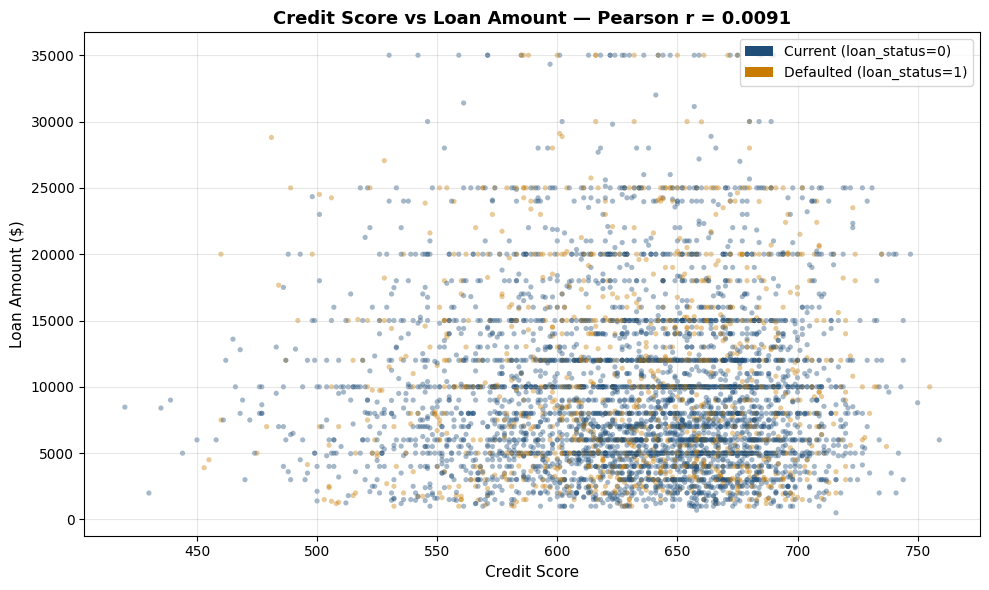

In [14]:
# Scatter plot using matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
sample = df.sample(5000, random_state=42)  # subsample for visual clarity
colors = sample['loan_status'].map({0: '#1F4E79', 1: '#C97B00'})
ax.scatter(sample['credit_score'], sample['loan_amnt'],
           c=colors, alpha=0.4, s=14, edgecolors='none')
ax.set_xlabel('Credit Score', fontsize=11)
ax.set_ylabel('Loan Amount ($)', fontsize=11)
ax.set_title('Credit Score vs Loan Amount — Pearson r = {:.4f}'.format(pearson),
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1F4E79', label='Current (loan_status=0)'),
    Patch(facecolor='#C97B00', label='Defaulted (loan_status=1)')
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig('q7_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation**

- Pearson correlation = **0.0091** — essentially **zero linear relationship** between credit score and loan amount.
- Spearman ρ = **0.0065** confirms there's no monotonic relationship either.
- Visually, the scatter is a featureless cloud — borrowers with credit scores of 400 receive loan amounts indistinguishable from borrowers with scores of 800.

> **Conclusion**: Loan sizing is **not credit-aware**. This is the second pricing anomaly we've found (Q3 showed flat rates across credit bands; Q7 shows flat sizing). Together they paint a concerning picture for the Risk Committee: the bank is not using its credit signal to differentiate either the price or the size of credit it extends. This warrants a complete review of the underwriting policy.

---
## Question 8 — Confidence Interval for Portfolio Default Rate

**Scenario**: the bank samples 500 loans and observes a 4% default rate. Estimate the true default rate of the full 100,000-loan portfolio.

**Approach**: 95% confidence interval for a population proportion using the normal approximation:

$$ \text{CI} = \hat{p} \pm z_{\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}} $$

(Normal approximation is valid because n·p̂ = 500 × 0.04 = 20 ≥ 5 and n·(1−p̂) = 480 ≥ 5.)

In [15]:
# Inputs given by the question
n      = 500
p_hat  = 0.04
z      = 1.96  # 95% confidence

# Standard error and margin
se     = np.sqrt(p_hat * (1 - p_hat) / n)
margin = z * se
ci_low  = p_hat - margin
ci_high = p_hat + margin

print(f'Sample default rate (p-hat): {p_hat * 100:.2f}%')
print(f'Standard error:              {se:.6f}')
print(f'Margin of error (95%):       +/-{margin * 100:.2f}%')
print(f'95% CI (rate):               ({ci_low * 100:.2f}%, {ci_high * 100:.2f}%)')
print()
print(f'Applied to the 100,000-loan portfolio:')
print(f'  Estimated defaults: {ci_low * 100000:,.0f} to {ci_high * 100000:,.0f} loans')

Sample default rate (p-hat): 4.00%
Standard error:              0.008764
Margin of error (95%):       +/-1.72%
95% CI (rate):               (2.28%, 5.72%)

Applied to the 100,000-loan portfolio:
  Estimated defaults: 2,282 to 5,718 loans


**Interpretation**

- We are 95% confident the true portfolio default rate falls between **2.28% and 5.72%**.
- Applied to the 100,000-loan portfolio, the bank should expect somewhere between **~2,300 and ~5,700 defaults**.
- The interval is **±1.7 percentage points wide**, which is meaningful — the upper bound (5.72%) is more than double the lower bound (2.28%). To narrow this, the bank would need a larger sample (the margin shrinks with √n).

**Sample size to halve the margin**: to cut the margin from ±1.7% to ±0.85%, the sample size would need to **quadruple** to 2,000 loans.

> **Risk Committee implication**: a single 500-loan sample is too imprecise for stress-test reporting. Recommend either (a) larger sample size, or (b) full-population computation using the warehouse rather than sampling.

---
## Question 12 — Primary and Foreign Keys: Linking Loan Application to Credit Bureau History

**Conceptual schema design** for two related tables that the bank needs to join for risk analysis.

### Table 1 — `loan_applications`

| Column | Role | Notes |
|---|---|---|
| `application_id` | **PK** (Primary Key) | Surrogate key, unique per application (e.g., `APP-000001`) |
| `borrower_id` | **FK** to borrowers | Links to the borrower master |
| `application_date` | attribute | Date the application was submitted |
| `loan_amnt` | attribute | Requested amount |
| `loan_intent` | attribute | Purpose of the loan |
| `loan_status` | attribute | Approved / Rejected / Pending |

### Table 2 — `credit_bureau_history`

| Column | Role | Notes |
|---|---|---|
| `bureau_record_id` | **PK** | Surrogate key for the bureau pull (one borrower can have many pulls over time) |
| `borrower_id` | **FK** to borrowers | Links to the borrower master |
| `pull_date` | attribute | When the bureau report was retrieved |
| `credit_score` | attribute | FICO/equivalent at pull time |
| `cb_person_cred_hist_length` | attribute | Years of credit history |
| `previous_loan_defaults_on_file` | attribute | Y/N flag |

### The link

Both tables share `borrower_id` as a **foreign key** referencing a master `borrowers` table.

```sql
SELECT
    la.application_id,
    la.loan_amnt,
    cb.credit_score,
    cb.previous_loan_defaults_on_file
FROM loan_applications la
JOIN credit_bureau_history cb
    ON la.borrower_id = cb.borrower_id
   AND cb.pull_date = (
       SELECT MAX(pull_date)
       FROM credit_bureau_history cb2
       WHERE cb2.borrower_id = la.borrower_id
         AND cb2.pull_date <= la.application_date
   );
```

### Design notes

- **Why surrogate keys (application_id, bureau_record_id) instead of natural keys?** Natural keys (e.g., bureau report number) can change format over time; surrogate integer/string keys are stable and join-efficient.
- **Why is `borrower_id` not the PK in either table?** Both tables have many-to-one relationships with the borrower (a borrower can apply for multiple loans and have multiple bureau pulls), so borrower_id alone cannot uniquely identify a row.
- **Why match `pull_date <= application_date`?** Risk modeling requires the credit score that was available **at the time the decision was made**, not the most recent score. Joining on the latest pull would create look-ahead bias.

---
## Summary of Findings

| Q | Topic | Key Result |
|---|---|---|
| 1 | 2NF/3NF normalization | 14 columns split into borrowers / credit_history / loans |
| 2 | FULL OUTER JOIN reconciliation | 408 funded loans missing application records — control failure |
| 3 | Interest rate variance | Variance flat across credit bands → pricing not standardized |
| 4 | T-test on income | p < 1e-300 — defaulted borrowers earn $26,271 less on average |
| 5 | DAX risk exposure | $108.6M (25.2% of $431.2M portfolio) currently in default |
| 7 | Credit score vs loan amount | r = 0.009 — loan sizing is not credit-aware |
| 8 | Default rate CI | Portfolio default rate: 2.28% to 5.72% (95% CI from n=500) |
| 12 | PK/FK design | Both tables link via borrower_id with proper temporal join logic |

### Risk Committee Recommendation Themes

1. **Underwriting review urgent** — Q3 and Q7 together show that neither rate nor size is differentiated by credit quality. The bank's risk pricing model needs immediate audit.
2. **Reconciliation gaps** — Q2 found 408 disbursements with no application record. Investigate and remediate within current quarter.
3. **Income as a primary signal** — Q4 confirms income strongly separates defaulters from current borrowers. Should be a featured input in default prediction models.
4. **Sample sizes for stress tests** — Q8 shows that 500-loan samples produce imprecise estimates (±1.7 ppt). Increase sample size or use full-population calculations.

In [16]:
# Close the SQLite connection
con.close()
print('Notebook complete.')

Notebook complete.
